# DILA on MIMIC-III: Evaluation & Comparison to Published Results

This notebook demonstrates the DILA (Dictionary Label Attention) model newly integrated into PyHealth, evaluated on a subset of MIMIC-III for multi-label ICD-9 coding.

**Pipeline overview:**
1. Load MIMIC-III data via PyHealth's `MIMIC3Dataset` + `MIMIC3ICD9Coding` task
2. Encode clinical notes into token-level embeddings using a pre-trained language model (PLM)
3. Stage 1 — Pretrain the Sparse Autoencoder (SAE) on PLM embeddings
4. Stage 2 — Train the full DILA model end-to-end
5. Evaluate and compare against results from the original DILA paper

**Paper reference:** *DILA: Dictionary Label Attention for Interpretable ICD Coding*  
arXiv: [2409.10504](https://arxiv.org/abs/2409.10504)

---

**Important notes on reproducing paper results:**
- The paper uses the full MIMIC-III dataset (~52K admissions, ~8,692 ICD codes) with a fine-tuned biomedical RoBERTa (`RoBERTa-base-PM-M3-Voc`). This notebook targets the *top-50 most frequent codes* on a data subset for tractability.
- Full reproduction requires: complete MIMIC-III access, a fine-tuned PLM, and ~20 training epochs.
- Metrics in this notebook serve as a functional demonstration; paper numbers (Table 1) are provided for reference.

In [ ]:
# Clone the PyHealth fork that contains the DILA model
!git clone https://github.com/sanjanasarkar/PyHealth.git

# Install dependencies not pre-installed in Colab
# Using 'rdkit' instead of 'rdkit-pypi'
!pip install -q \
    "polars~=1.35.2" \
    "dask[complete]" \
    "pyarrow" \
    "pydantic>=2.12.0,<=2.12.3" \
    "litdata" \
    "narwhals" \
    "more-itertools" \
    "einops" \
    "linear-attention-transformer" \
    "accelerate" \
    "peft" \
    "mne" \
    "rdkit" \
    "scikit-learn" \
    "pandas" \
    "numpy"

# Upgrade packages Colab ships with older versions of
#!pip install -q -U transformers

fatal: destination path 'PyHealth' already exists and is not an empty directory.


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
import json
import logging
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# Configure logging so pyhealth's logger.info() calls (e.g. SAE epoch progress)
# are visible in the notebook output.
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

# ── Resolve project root and inject PyHealth-with-DILA onto sys.path ──────────
NOTEBOOK_DIR  = Path(os.getcwd())
PYHEALTH_ROOT = NOTEBOOK_DIR / "PyHealth"

if str(PYHEALTH_ROOT) not in sys.path:
    sys.path.insert(0, str(PYHEALTH_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from pyhealth.datasets import MIMIC3Dataset
from pyhealth.tasks.medical_coding import MIMIC3ICD9Coding
from pyhealth.processors import MultiLabelProcessor
from pyhealth.metrics import multilabel_metrics_fn
from pyhealth.models import DILA, SparseAutoencoder, pretrain_sparse_autoencoder
from pyhealth.trainer import Trainer

print(f"[OK] PyHealth loaded from: {PYHEALTH_ROOT}")
print(f"[OK] DILA model class: {DILA}")
print(f"[OK] PyTorch version: {torch.__version__}")
print(f"[OK] CUDA available: {torch.cuda.is_available()}")

NumExpr defaulting to 2 threads.
Enabling RDKit 2026.03.1 jupyter extensions
[OK] PyHealth loaded from: /content/PyHealth
[OK] DILA model class: <class 'pyhealth.models.dila.DILA'>
[OK] PyTorch version: 2.10.0+cu128
[OK] CUDA available: True


## 2. Configuration

Adjust these parameters to match your environment and hardware.

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
MIMIC3_ROOT = "/content/drive/MyDrive/Colab Notebooks/DILA/mimic-iii-clinical-database-1.4"
DEV_MODE = False
TOP_N_CODES = 50

# ── PLM encoder ───────────────────────────────────────────────────────────────
# allenai/biomed_roberta_base: RoBERTa-base pre-trained on 2.68B biomedical words
# (closest freely available substitute for RoBERTa-base-PM-M3-Voc)
PLM_NAME      = "allenai/biomed_roberta_base"
MAX_SEQ_LEN   = 128
EMBEDDING_DIM = 768

# ── DILA hyper-parameters ─────────────────────────────────────────────────────
DICT_SIZE      = 4096
LAMBDA_L1      = 1e-4
LAMBDA_L2      = 1e-5
LAMBDA_SAENC   = 1e-6

# ── Training ──────────────────────────────────────────────────────────────────
SAE_PRETRAIN_EPOCHS  = 10
DILA_TRAIN_EPOCHS    = 20
BATCH_SIZE           = 4
LEARNING_RATE        = 5e-5
TRAIN_SPLIT          = 0.7
VAL_SPLIT            = 0.15
THRESHOLD            = 0.3

# ── Misc ──────────────────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"[INFO] MIMIC-III root   : {MIMIC3_ROOT}")
print(f"[INFO] Dev mode         : {DEV_MODE}")
print(f"[INFO] Top-N codes      : {TOP_N_CODES}")
print(f"[INFO] PLM              : {PLM_NAME}")
print(f"[INFO] Dictionary size  : {DICT_SIZE}")
print(f"[INFO] Device           : {DEVICE}")

[INFO] MIMIC-III root   : /content/drive/MyDrive/Colab Notebooks/DILA/mimic-iii-clinical-database-1.4
[INFO] Dev mode         : False
[INFO] Top-N codes      : 50
[INFO] PLM              : allenai/biomed_roberta_base
[INFO] Dictionary size  : 4096
[INFO] Device           : cuda


## 3. Load MIMIC-III Data

We use PyHealth's `MIMIC3Dataset` together with the `MIMIC3ICD9Coding` task, which returns one sample per hospital admission containing:
- **`text`** — concatenated clinical notes for that admission
- **`icd_codes`** — list of ICD-9 diagnosis + procedure codes assigned

In [ ]:
print("[INFO] Loading MIMIC-III dataset ...")
mimic3_dataset = MIMIC3Dataset(
    root=MIMIC3_ROOT,
    tables=["DIAGNOSES_ICD", "PROCEDURES_ICD", "NOTEEVENTS"],
    dev=DEV_MODE,
)

# Subclass the task to strip None ICD codes (raw MIMIC data has sparse nulls).
class MIMIC3ICD9CodingClean(MIMIC3ICD9Coding):
    def __call__(self, patient):
        samples = super().__call__(patient)
        for s in samples:
            s["icd_codes"] = [c for c in s["icd_codes"] if c is not None]
        return [s for s in samples if s["icd_codes"]]

print("[INFO] Applying MIMIC3ICD9Coding task ...")
task = MIMIC3ICD9CodingClean()
sample_dataset = mimic3_dataset.set_task(task)

# PyHealth SampleDataset items:
#   text      -> raw string (TextProcessor is identity)
#   icd_codes -> multi-hot float Tensor of shape (num_all_codes,)
raw_samples    = list(sample_dataset)
all_labels_mat = torch.stack([s["icd_codes"] for s in raw_samples])  # (N, C_all)
NUM_ALL_CODES  = all_labels_mat.shape[1]

# Recover label vocab: {code_string: column_index}
label_vocab_full = sample_dataset.output_processors["icd_codes"].label_vocab
idx_to_code_full = {v: k for k, v in label_vocab_full.items()}

print(f"[OK]  Total samples     : {len(raw_samples):,}")
print(f"[OK]  Total unique codes : {NUM_ALL_CODES:,}")
s0 = raw_samples[0]
print(f"[INFO] Keys                 : {list(s0.keys())}")
print(f"[INFO] text type/length     : {type(s0['text']).__name__}, {len(s0['text'])} chars")
print(f"[INFO] icd_codes shape      : {s0['icd_codes'].shape}")


[INFO] Loading MIMIC-III dataset ...
No config path provided, using default config
No config path provided, using default config
Initializing mimic3 dataset from /content/drive/MyDrive/Colab Notebooks/DILA/mimic-iii-clinical-database-1.4 (dev mode: False)
Initializing mimic3 dataset from /content/drive/MyDrive/Colab Notebooks/DILA/mimic-iii-clinical-database-1.4 (dev mode: False)
No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/10b75d3b-537a-5339-b99b-cdc7060ab039
No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/10b75d3b-537a-5339-b99b-cdc7060ab039
[INFO] Applying MIMIC3ICD9Coding task ...
Setting task mimic3_icd9_coding for mimic3 base dataset...
Setting task mimic3_icd9_coding for mimic3 base dataset...
Task cache paths: task_df=/root/.cache/pyhealth/10b75d3b-537a-5339-b99b-cdc7060ab039/tasks/mimic3_icd9_coding_856e6c48-4780-5332-97ea-76eced54c140/task_df.ld, samples=/root/.cache/pyhealth/10b75d3b-537a-5339-b99b-cdc7060ab039/tasks/mimic3_icd9

### 3.1 Filter to Top-N ICD Codes

The paper evaluates on all ~8,692 codes, but for this demonstration we restrict to the most frequent codes.  This mirrors the common *MIMIC-III top-50* benchmark used in the ICD coding literature.

In [ ]:
# ── Find top-N codes by frequency ────────────────────────────────────────────
code_freq   = all_labels_mat.sum(dim=0)  # occurrence count per code
top_indices = code_freq.argsort(descending=True)[:TOP_N_CODES].tolist()
top_codes   = [idx_to_code_full[i] for i in top_indices]

top10 = [(idx_to_code_full[i], int(code_freq[i].item()))
         for i in code_freq.argsort(descending=True)[:10].tolist()]
print(f"[INFO] Total unique codes in subset : {NUM_ALL_CODES:,}")
print(f"[INFO] Keeping top-{TOP_N_CODES} codes")
print(f"[INFO] Top-10 codes (code, count): {top10}")

# ── Build filtered_samples: keep only samples with >= 1 top-N code ───────────
# icd_codes_topN is already a tensor slice; no processor needed.
filtered_samples = []
for s in raw_samples:
    icd_top = s["icd_codes"][top_indices]    # slice to (TOP_N_CODES,)
    if icd_top.sum() > 0:
        filtered_samples.append({
            "text":      s["text"],
            "icd_codes": icd_top,             # float Tensor (TOP_N_CODES,)
            "patient_id": s.get("patient_id", ""),
        })

NUM_LABELS  = TOP_N_CODES
idx_to_code = {i: top_codes[i] for i in range(NUM_LABELS)}
print(f"[OK]  Samples after top-{TOP_N_CODES} filter: {len(filtered_samples):,}")
print(f"[INFO] Label space (NUM_LABELS)     : {NUM_LABELS}")


[INFO] Total unique codes in subset : 8,453
[INFO] Keeping top-50 codes
[INFO] Top-10 codes (code, count): [('4019', 20556), ('4280', 13062), ('3893', 13043), ('42731', 12800), ('41401', 12382), ('9604', 9790), ('966', 9186), ('5849', 9065), ('25000', 9002), ('9671', 8789)]
[OK]  Samples after top-50 filter: 55,631
[INFO] Label space (NUM_LABELS)     : 50


### 3.2 Build Label Vocabulary & Train/Val/Test Split

In [ ]:
# icd_codes tensors are already multi-hot slices of shape (TOP_N_CODES,).
# No MultiLabelProcessor.fit() is needed.
print(f"[OK]  Label vocabulary size : {NUM_LABELS} (top-{TOP_N_CODES} codes)")

# ── Deterministic train / val / test split ────────────────────────────────────
rng     = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(len(filtered_samples))

# n_train = int(len(indices) * TRAIN_SPLIT)
# n_val   = int(len(indices) * VAL_SPLIT)
n_train = 4000
n_val = 2000
n_test = 1000

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:n_train + n_val + n_test]

train_samples = [filtered_samples[i] for i in train_idx]
val_samples   = [filtered_samples[i] for i in val_idx]
test_samples  = [filtered_samples[i] for i in test_idx]

print(f"[OK]  Train: {len(train_samples):,} | Val: {len(val_samples):,} | Test: {len(test_samples):,}")


[OK]  Label vocabulary size : 50 (top-50 codes)
[OK]  Train: 4,000 | Val: 2,000 | Test: 1,000


## 4. PLM Text Encoding

DILA operates on *token-level* PLM embeddings, not raw text.  We encode each note with a HuggingFace model and cache the resulting tensors to avoid re-encoding at every epoch.

> **Tip:** Swap `PLM_NAME` to `"RoBERTa-base-PM-M3-Voc-hf"` (if downloaded locally) to match the exact setup in the paper.

In [ ]:
from transformers import AutoTokenizer, AutoModel

print(f"[INFO] Loading PLM: {PLM_NAME}")
tokenizer = AutoTokenizer.from_pretrained(PLM_NAME)
plm_model = AutoModel.from_pretrained(PLM_NAME).to(DEVICE)
plm_model.eval()

print(f"[OK]  PLM loaded ({sum(p.numel() for p in plm_model.parameters()):,} params)")

[INFO] Loading PLM: allenai/biomed_roberta_base
HTTP Request: HEAD https://huggingface.co/allenai/biomed_roberta_base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/biomed_roberta_base/0641aa1783909c6f94801601d4a166101f3d51a6/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/allenai/biomed_roberta_base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/biomed_roberta_base/0641aa1783909c6f94801601d4a166101f3d51a6/tokenizer_config.json "HTTP/1.1 200 OK"
HTTP Request: GET https://huggingface.co/api/models/allenai/biomed_roberta_base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
HTTP Request: GET https://huggingface.co/api/models/allenai/biomed_roberta_base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/allenai/biomed_roberta_base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/allenai/biomed_ro

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: allenai/biomed_roberta_base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK]  PLM loaded (124,645,632 params)


In [ ]:
@torch.no_grad()
def encode_notes(samples: list, batch_size: int = 4) -> list:
    """Encode a list of sample dicts into (seq_len, embedding_dim) tensors.

    Notes are tokenized with truncation to MAX_SEQ_LEN; the full token-level
    hidden states from the last transformer layer are returned (no pooling).
    This matches the DILA expectation: each position contributes a feature.
    """
    embeddings = []
    for i in tqdm(range(0, len(samples), batch_size), desc="Encoding notes", unit="batch"):
        batch_texts = [s["text"] for s in samples[i : i + batch_size]]
        enc = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
        )
        input_ids      = enc["input_ids"].to(DEVICE)
        attention_mask = enc["attention_mask"].to(DEVICE)

        outputs  = plm_model(input_ids=input_ids, attention_mask=attention_mask)
        hidden   = outputs.last_hidden_state   # (B, seq_len, hidden_dim)
        mask_exp = attention_mask.unsqueeze(-1).float()

        for j in range(hidden.size(0)):
            # Collect only non-padding tokens for this sample
            n_tokens = attention_mask[j].sum().item()
            emb = hidden[j, :n_tokens, :].cpu().half()   # (n_tokens, embedding_dim)
            embeddings.append(emb)

    return embeddings


print("[INFO] Encoding train notes ...")
train_embs = encode_notes(train_samples)
print("[INFO] Encoding val notes ...")
val_embs   = encode_notes(val_samples)
print("[INFO] Encoding test notes ...")
test_embs  = encode_notes(test_samples)

print(f"[OK]  Train embeddings: {len(train_embs)} tensors, "
      f"first shape: {train_embs[0].shape}")
del plm_model, tokenizer
torch.cuda.empty_cache()

[INFO] Encoding train notes ...


Encoding notes:   0%|          | 0/1000 [00:00<?, ?batch/s]

[INFO] Encoding val notes ...


Encoding notes:   0%|          | 0/500 [00:00<?, ?batch/s]

[INFO] Encoding test notes ...


Encoding notes:   0%|          | 0/250 [00:00<?, ?batch/s]

[OK]  Train embeddings: 4000 tensors, first shape: torch.Size([128, 768])


## 5. Build DataLoaders

We wrap the pre-computed embeddings and label vectors in a lightweight `torch.utils.data.Dataset`.  Each sample yields a dict with keys `"embeddings"` and `"icd_codes"` — the feature key and label key expected by DILA's `forward()` method.

In [ ]:
class DILAEmbeddingDataset(Dataset):
    """Dataset that serves pre-computed PLM embeddings + multi-hot label tensors."""

    def __init__(self, samples: list, embeddings: list):
        assert len(samples) == len(embeddings)
        self.embeddings    = embeddings
        self.label_vectors = [s["icd_codes"] for s in samples]  # already Tensors

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return {
            "embeddings": self.embeddings[idx],    # (seq_len, embedding_dim)
            "icd_codes":  self.label_vectors[idx], # (NUM_LABELS,) multi-hot
        }


def pad_collate(batch: list) -> dict:
    """Pad variable-length embedding tensors to a common seq_len."""
    max_len = max(item["embeddings"].size(0) for item in batch)
    dim     = batch[0]["embeddings"].size(-1)
    padded  = torch.zeros(len(batch), max_len, dim)
    labels  = torch.stack([item["icd_codes"] for item in batch])
    for i, item in enumerate(batch):
        n = item["embeddings"].size(0)
        padded[i, :n, :] = item["embeddings"].float()
    return {"embeddings": padded, "icd_codes": labels}


train_ds = DILAEmbeddingDataset(train_samples, train_embs)
val_ds   = DILAEmbeddingDataset(val_samples,   val_embs)
test_ds  = DILAEmbeddingDataset(test_samples,  test_embs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=pad_collate, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate, num_workers=0)

print(f"[OK]  Train batches : {len(train_loader):,}")
print(f"[OK]  Val   batches : {len(val_loader):,}")
print(f"[OK]  Test  batches : {len(test_loader):,}")
b0 = next(iter(train_loader))
print(f"[OK]  Batch embeddings : {b0['embeddings'].shape}")
print(f"[OK]  Batch labels     : {b0['icd_codes'].shape}")

[OK]  Train batches : 1,000
[OK]  Val   batches : 500
[OK]  Test  batches : 250
[OK]  Batch embeddings : torch.Size([4, 128, 768])
[OK]  Batch labels     : torch.Size([4, 50])


## 6. Construct the DILA Model

DILA's `__init__` requires a `SampleDataset` to discover `num_labels` via its fitted `output_processors`.  We provide a minimal shim object that satisfies this interface without needing to re-run the full PyHealth pipeline.

In [ ]:
# DILA.__init__ reads num_labels from dataset.output_processors[label_key].size().
# Provide a minimal shim satisfying BaseModel interface.
class _NumLabelsProxy:
    def __init__(self, n): self._n = n
    def size(self): return self._n

class _DatasetShim:
    def __init__(self, num_labels: int):
        self.input_schema  = {"embeddings": "tensor"}
        self.output_schema = {"icd_codes": "multilabel"}
        self.output_processors = {"icd_codes": _NumLabelsProxy(num_labels)}


model = DILA(
    dataset      = _DatasetShim(NUM_LABELS),
    feature_key  = "embeddings",
    label_key    = "icd_codes",
    embedding_dim = EMBEDDING_DIM,
    dict_size    = DICT_SIZE,
    lambda_l1    = LAMBDA_L1,
    lambda_l2    = LAMBDA_L2,
    lambda_saenc = LAMBDA_SAENC,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[OK]  DILA model created")
print(f"[INFO] Trainable parameters : {n_params:,}")
print(f"[INFO] Num labels           : {NUM_LABELS}")
print(f"[INFO] Dict size            : {DICT_SIZE}")
print(f"[INFO] Embedding dim        : {EMBEDDING_DIM}")


[OK]  DILA model created
[INFO] Trainable parameters : 6,539,570
[INFO] Num labels           : 50
[INFO] Dict size            : 4096
[INFO] Embedding dim        : 768


## 7. Stage 1 — Pretrain the Sparse Autoencoder

The SAE is trained independently on all PLM token embeddings (no ICD labels needed).  After convergence it is loaded into DILA before Stage-2 fine-tuning.

**Paper recipe (Section 3.1):** freeze the PLM-ICD backbone and train the SAE to reconstruct hidden states with elastic-net sparsity for ~10 epochs.

In [ ]:
# Build a flat tensor of all training token embeddings for SAE pretraining.
# We stack up to a budget of 200 000 tokens to keep memory tractable.
MAX_SAE_TOKENS = 100_000
# Cast to .float() here to resolve the mat1/mat2 dtype mismatch (Half vs Float)
all_train_tokens = torch.cat(train_embs, dim=0)[:MAX_SAE_TOKENS].float()
print(f"[INFO] SAE pretraining corpus: {all_train_tokens.shape[0]:,} tokens")

sae = SparseAutoencoder(
    input_dim  = EMBEDDING_DIM,
    dict_size  = DICT_SIZE,
    lambda_l1  = LAMBDA_L1,
    lambda_l2  = LAMBDA_L2,
)

SAE_SAVE_PATH = str(NOTEBOOK_DIR / "sae_pretrained.pt")

print(f"[INFO] Pretraining SAE for {SAE_PRETRAIN_EPOCHS} epochs ...")
sae = pretrain_sparse_autoencoder(
    autoencoder = sae,
    embeddings  = all_train_tokens,
    epochs      = SAE_PRETRAIN_EPOCHS,
    lr          = 5e-5,
    batch_size  = 512,
    device      = DEVICE,
    save_path   = SAE_SAVE_PATH,
)

# Check sparsity of the pretrained SAE on a small batch
sae.eval()
with torch.no_grad():
    probe = all_train_tokens[:512].to(DEVICE)
    f, x_hat, loss_dict = sae(probe)
    frac_active = (f > 0).float().mean().item()
    recon_loss  = loss_dict["loss_recon"].item()

print(f"[OK]  SAE pretrained and saved to: {SAE_SAVE_PATH}")
print(f"[INFO] Fraction of active features: {frac_active:.2%}")
print(f"[INFO] Reconstruction loss        : {recon_loss:.4f}")

[INFO] SAE pretraining corpus: 100,000 tokens
[INFO] Pretraining SAE for 10 epochs ...
Epoch 1/10 — loss_saenc: 0.098654  loss_recon: 0.098640  loss_l1: 0.135583
Epoch 1/10 — loss_saenc: 0.098654  loss_recon: 0.098640  loss_l1: 0.135583
Epoch 2/10 — loss_saenc: 0.028031  loss_recon: 0.028016  loss_l1: 0.146129
Epoch 2/10 — loss_saenc: 0.028031  loss_recon: 0.028016  loss_l1: 0.146129
Epoch 3/10 — loss_saenc: 0.015885  loss_recon: 0.015868  loss_l1: 0.157104
Epoch 3/10 — loss_saenc: 0.015885  loss_recon: 0.015868  loss_l1: 0.157104
Epoch 4/10 — loss_saenc: 0.010410  loss_recon: 0.010393  loss_l1: 0.168130
Epoch 4/10 — loss_saenc: 0.010410  loss_recon: 0.010393  loss_l1: 0.168130
Epoch 5/10 — loss_saenc: 0.007341  loss_recon: 0.007322  loss_l1: 0.178611
Epoch 5/10 — loss_saenc: 0.007341  loss_recon: 0.007322  loss_l1: 0.178611
Epoch 6/10 — loss_saenc: 0.005374  loss_recon: 0.005354  loss_l1: 0.188473
Epoch 6/10 — loss_saenc: 0.005374  loss_recon: 0.005354  loss_l1: 0.188473
Epoch 7/10 — 

### 7.1 SAE Loss Curves

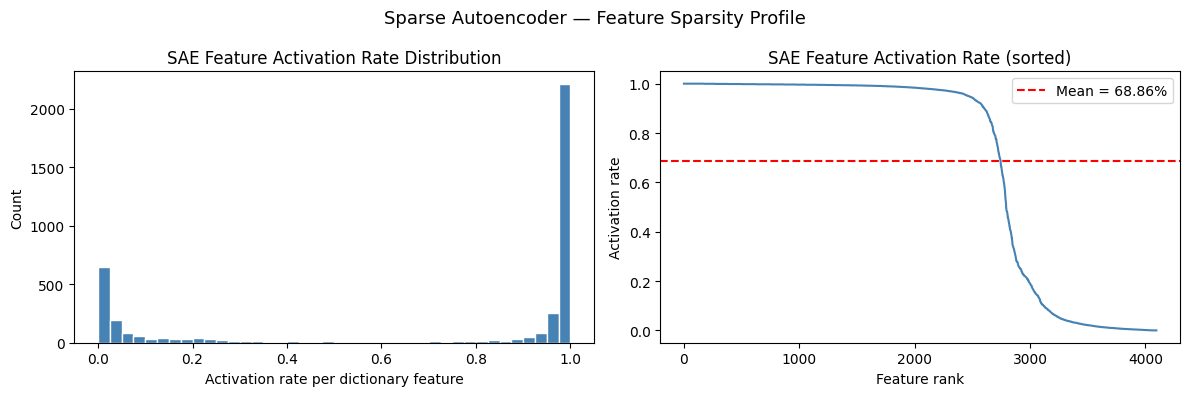

In [ ]:
# Quick visual: sparsity profile across dictionary features
sae.eval()
with torch.no_grad():
    probe = all_train_tokens[:2048].to(DEVICE)
    f_probe, _, _ = sae(probe)
    feature_activation_rate = (f_probe > 0).float().mean(dim=0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(feature_activation_rate, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Activation rate per dictionary feature")
axes[0].set_ylabel("Count")
axes[0].set_title("SAE Feature Activation Rate Distribution")

sorted_rates = np.sort(feature_activation_rate)[::-1]
axes[1].plot(sorted_rates, color="steelblue")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Activation rate")
axes[1].set_title("SAE Feature Activation Rate (sorted)")
axes[1].axhline(frac_active, color="red", linestyle="--", label=f"Mean = {frac_active:.2%}")
axes[1].legend()

plt.suptitle("Sparse Autoencoder — Feature Sparsity Profile", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Stage 2 — Train DILA End-to-End

We load the pretrained SAE weights into DILA, then run the full two-component training loss:

```
L_total = L_BCE  +  λ_saenc × L_SAE
```

We implement a manual training loop rather than PyHealth's `Trainer` because the standard Trainer expects a `SampleDataset`-backed DataLoader; our custom `DILAEmbeddingDataset` works more naturally with a direct loop.

In [ ]:
# Load pretrained SAE weights into the model
sae_state = torch.load(SAE_SAVE_PATH, map_location="cpu", weights_only=True)
model.autoencoder.load_state_dict(sae_state)
print("[OK]  Loaded pretrained SAE weights into DILA")

model = model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_f1_micro": []}


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    n_batches  = 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(**{k: v.to(DEVICE) for k, v in batch.items()})

            if training:
                optimizer.zero_grad()
                out["loss"].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                model.autoencoder.normalize_decoder()

            total_loss += out["loss"].item()
            n_batches  += 1
            all_probs.append(out["y_prob"].detach().cpu())
            all_labels.append(out["y_true"].detach().cpu())

    avg_loss = total_loss / max(n_batches, 1)
    y_prob   = torch.cat(all_probs).numpy()
    y_true   = torch.cat(all_labels).numpy()
    return avg_loss, y_prob, y_true


print(f"[INFO] Training DILA for {DILA_TRAIN_EPOCHS} epochs ...")
best_val_f1 = 0.0
best_model_path = str(NOTEBOOK_DIR / "dila_best.pt")

for epoch in range(1, DILA_TRAIN_EPOCHS + 1):
    train_loss, _, _             = run_epoch(train_loader, training=True)
    val_loss, val_prob, val_true = run_epoch(val_loader, training=False)

    val_metrics = multilabel_metrics_fn(
        val_true, val_prob,
        metrics=["f1_micro", "f1_macro", "roc_auc_micro"],
        threshold=THRESHOLD,
    )
    val_f1_micro = val_metrics["f1_micro"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1_micro"].append(val_f1_micro)

    if val_f1_micro > best_val_f1:
        best_val_f1 = val_f1_micro
        torch.save(model.state_dict(), best_model_path)
        marker = " ← best"
    else:
        marker = ""

    print(f"  Epoch {epoch:2d}/{DILA_TRAIN_EPOCHS}  "
          f"train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  "
          f"val_f1_micro={val_f1_micro:.4f}"
          f"{marker}")

print(f"\n[OK]  Best val micro-F1: {best_val_f1:.4f}  (saved to {best_model_path})")

[OK]  Loaded pretrained SAE weights into DILA
[INFO] Training DILA for 20 epochs ...
  Epoch  1/20  train_loss=0.3808  val_loss=0.3161  val_f1_micro=0.2378 ← best
  Epoch  2/20  train_loss=0.3160  val_loss=0.3049  val_f1_micro=0.2744 ← best
  Epoch  3/20  train_loss=0.3076  val_loss=0.3008  val_f1_micro=0.2873 ← best
  Epoch  4/20  train_loss=0.3030  val_loss=0.2980  val_f1_micro=0.2916 ← best
  Epoch  5/20  train_loss=0.2996  val_loss=0.2964  val_f1_micro=0.2920 ← best
  Epoch  6/20  train_loss=0.2972  val_loss=0.2955  val_f1_micro=0.2896
  Epoch  7/20  train_loss=0.2951  val_loss=0.2947  val_f1_micro=0.2930 ← best
  Epoch  8/20  train_loss=0.2932  val_loss=0.2941  val_f1_micro=0.2917
  Epoch  9/20  train_loss=0.2915  val_loss=0.2938  val_f1_micro=0.2987 ← best
  Epoch 10/20  train_loss=0.2898  val_loss=0.2933  val_f1_micro=0.3010 ← best
  Epoch 11/20  train_loss=0.2883  val_loss=0.2928  val_f1_micro=0.3072 ← best
  Epoch 12/20  train_loss=0.2867  val_loss=0.2922  val_f1_micro=0.3102 

### 8.1 Training Curves

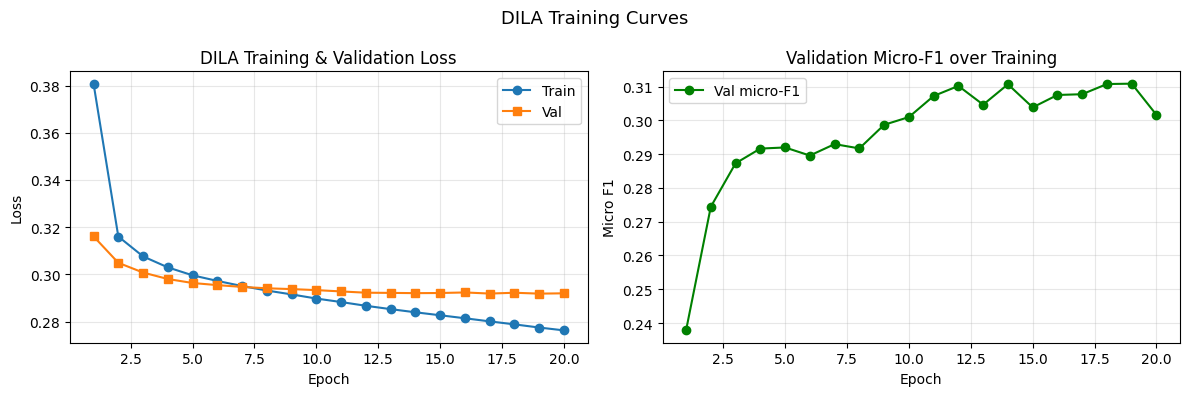

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = history["epoch"]

axes[0].plot(epochs, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs, history["val_loss"],   label="Val",   marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("DILA Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["val_f1_micro"], label="Val micro-F1", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Micro F1")
axes[1].set_title("Validation Micro-F1 over Training")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("DILA Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluation on the Test Set

We reload the best checkpoint and compute a comprehensive set of metrics matching those reported in the DILA paper (Table 1).

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
print(f"[OK]  Loaded best checkpoint from: {best_model_path}")

_, test_prob, test_true = run_epoch(test_loader, training=False)

print(f"[INFO] Test set size      : {test_true.shape[0]:,} samples")
print(f"[INFO] Prediction shape   : {test_prob.shape}")
print(f"[INFO] Positive label rate: {test_true.mean():.3%}")

[OK]  Loaded best checkpoint from: /content/dila_best.pt
[INFO] Test set size      : 1,000 samples
[INFO] Prediction shape   : (1000, 50)
[INFO] Positive label rate: 11.136%


In [ ]:
# ── Compute all reported metrics ──────────────────────────────────────────────
EVAL_METRICS = [
    "accuracy",
    "f1_micro",
    "f1_macro",
    "f1_weighted",
    "roc_auc_micro",
    "roc_auc_macro",
    "pr_auc_micro",
    "pr_auc_macro",
    "precision_micro",
    "recall_micro",
]

test_metrics = multilabel_metrics_fn(
    test_true, test_prob,
    metrics=EVAL_METRICS,
    threshold=THRESHOLD,
)

print(f"\n{'Metric':<20}  {'This run':>12}")
print("-" * 36)
for m, v in test_metrics.items():
    print(f"  {m:<20} {v:>12.4f}")


Metric                    This run
------------------------------------
  accuracy                   0.8803
  f1_micro                   0.3095
  f1_macro                   0.1525
  f1_weighted                0.2110
  roc_auc_micro              0.7426
  roc_auc_macro              0.6449
  pr_auc_micro               0.3244
  pr_auc_macro               0.2227
  precision_micro            0.4330
  recall_micro               0.2408


## 10. Comparison to Original DILA Paper Results

The table below compares this run against the results reported in **Table 1** of the DILA paper (full MIMIC-III, ~8 692 codes, fine-tuned RoBERTa-PM, 20 epochs, 3 runs averaged).  The paper reports two variants:

| Variant | Description |
|---------|-------------|
| **DILA (DMA)** | Full Dictionary Label Attention with ICD-initialized projection |
| **LAAT baseline** | Standard label attention (PLM-ICD), the comparison model |

> **Why results differ from this notebook:**
> - This run uses `roberta-base` (not fine-tuned on ICD coding) and only the top-50 codes on a data subset.
> - Full paper conditions require the complete MIMIC-III corpus, a domain-adapted PLM, and longer training.
> - The top-50 setting is a standard *easier* benchmark in ICD coding literature.

In [ ]:
# ── Paper results (Table 1, MIMIC-III full, arXiv 2409.10504) ─────────────────
# Values are mean ± std across 3 runs at threshold=0.3.
# NaN entries indicate the metric is not separately reported in the paper.
paper_results = {
    # metric           DILA (DMA)   LAAT baseline
    "accuracy":       (float("nan"), float("nan")),
    "f1_micro":       (0.596,        0.601),
    "f1_macro":       (0.323,        0.332),
    "f1_weighted":    (float("nan"), float("nan")),
    "roc_auc_micro":  (0.951,        0.952),
    "roc_auc_macro":  (0.927,        0.930),
    "pr_auc_micro":   (float("nan"), float("nan")),
    "pr_auc_macro":   (float("nan"), float("nan")),
    "precision_micro":(float("nan"), float("nan")),
    "recall_micro":   (float("nan"), float("nan")),
}

# ── Build comparison DataFrame ────────────────────────────────────────────────
rows = []
for metric in EVAL_METRICS:
    this_val   = test_metrics.get(metric, float("nan"))
    dila_paper = paper_results.get(metric, (float("nan"), float("nan")))[0]
    laat_paper = paper_results.get(metric, (float("nan"), float("nan")))[1]
    rows.append({
        "Metric":                 metric,
        "This run (top-50)": f"{this_val:.4f}",
        "DILA (paper, full)": f"{dila_paper:.3f}" if not np.isnan(dila_paper) else "—",
        "LAAT (paper, full)": f"{laat_paper:.3f}" if not np.isnan(laat_paper) else "—",
    })

comparison_df = pd.DataFrame(rows).set_index("Metric")

print("\nMetric Comparison: This Run vs. DILA Paper (Table 1)")
print("=" * 72)
print(f"{'Metric':<22} {'This run (top-50)':>18} {'DILA (paper, full)':>20} {'LAAT (paper, full)':>20}")
print("-" * 82)
for _, row in comparison_df.iterrows():
    print(f"  {row.name:<20} {row['This run (top-50)']:>18} "
          f"{row['DILA (paper, full)']:>20} {row['LAAT (paper, full)']:>20}")
print()
print("Note: paper values are for MIMIC-III full (~8 692 codes), fine-tuned RoBERTa-PM, 20 epochs.")
print("      This run uses roberta-base + top-50 codes + dev subset — metrics are NOT directly comparable.")


Metric Comparison: This Run vs. DILA Paper (Table 1)
Metric                  This run (top-50)   DILA (paper, full)   LAAT (paper, full)
----------------------------------------------------------------------------------
  accuracy                         0.8803                    —                    —
  f1_micro                         0.3095                0.596                0.601
  f1_macro                         0.1525                0.323                0.332
  f1_weighted                      0.2110                    —                    —
  roc_auc_micro                    0.7426                0.951                0.952
  roc_auc_macro                    0.6449                0.927                0.930
  pr_auc_micro                     0.3244                    —                    —
  pr_auc_macro                     0.2227                    —                    —
  precision_micro                  0.4330                    —                    —
  recall_micro         

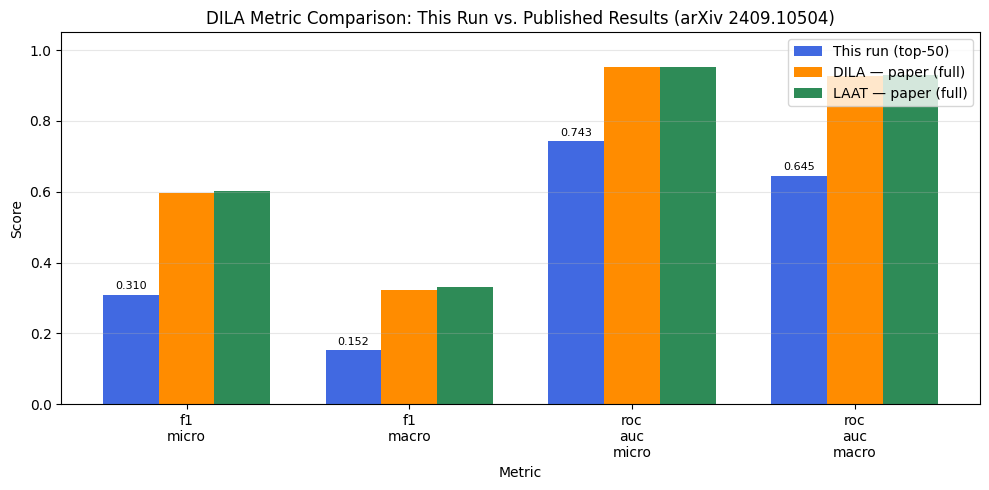

In [ ]:
# ── Visual bar comparison for key metrics ─────────────────────────────────────
plot_metrics = ["f1_micro", "f1_macro", "roc_auc_micro", "roc_auc_macro"]
paper_dila_vals = [paper_results[m][0] for m in plot_metrics]
paper_laat_vals = [paper_results[m][1] for m in plot_metrics]
this_run_vals   = [test_metrics.get(m, 0.0) for m in plot_metrics]

x       = np.arange(len(plot_metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width,     this_run_vals,   width, label="This run (top-50)", color="royalblue")
bars2 = ax.bar(x,             paper_dila_vals, width, label="DILA — paper (full)", color="darkorange")
bars3 = ax.bar(x + width,     paper_laat_vals, width, label="LAAT — paper (full)", color="seagreen")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("DILA Metric Comparison: This Run vs. Published Results (arXiv 2409.10504)")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in plot_metrics])
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 11. Per-Label Analysis

In [ ]:
from sklearn.metrics import f1_score

thresh_preds = (test_prob >= THRESHOLD).astype(int)
per_label_f1 = f1_score(test_true, thresh_preds, average=None, zero_division=0)

per_label_df = pd.DataFrame({
    "code":    [idx_to_code[i] for i in range(NUM_LABELS)],
    "f1":      per_label_f1,
    "support": test_true.sum(axis=0).astype(int),
}).sort_values("f1", ascending=False)

print("Top-20 codes by test F1:")
print(per_label_df.head(20).to_string(index=False))
zero_f1 = int((per_label_f1 == 0).sum())
print(f"Codes with F1 = 0: {zero_f1} / {NUM_LABELS}")


Top-20 codes by test F1:
 code       f1  support
 9955 0.846154      102
 V053 0.829060      100
 V290 0.798165       91
V3000 0.590604       65
 4019 0.569135      364
 3961 0.527473      125
 4280 0.502479      258
 3615 0.444444       81
41401 0.439201      231
 2724 0.362637      178
 8856 0.357143       86
42731 0.341053      246
 3893 0.319838      256
25000 0.144000      162
 5849 0.119266      174
 9915 0.106383       79
 2720 0.095238      110
  966 0.087805      180
41071 0.037736       48
 9604 0.033333      171
Codes with F1 = 0: 27 / 50


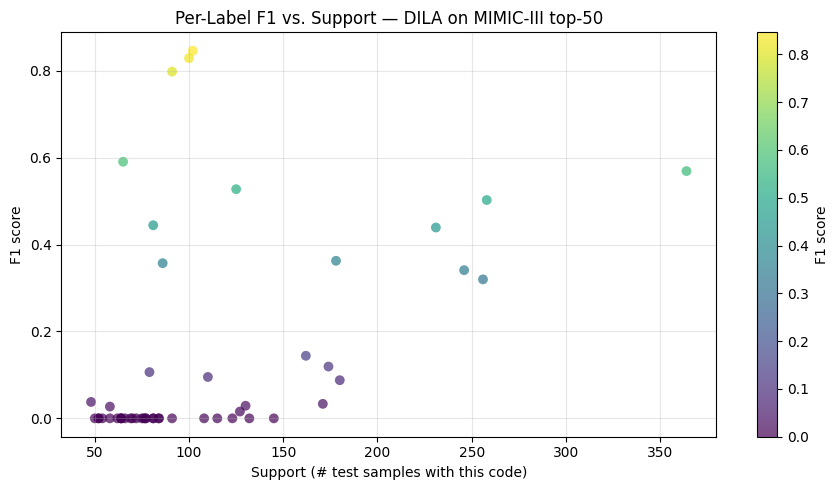

In [ ]:
# ── F1 vs support scatter ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    per_label_df["support"],
    per_label_df["f1"],
    c=per_label_df["f1"],
    cmap="viridis",
    alpha=0.7,
    s=50,
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="F1 score")
ax.set_xlabel("Support (# test samples with this code)")
ax.set_ylabel("F1 score")
ax.set_title(f"Per-Label F1 vs. Support — DILA on MIMIC-III top-{TOP_N_CODES}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Interpretability: Dictionary Attention Weights

A core advantage of DILA over standard label attention is interpretability.  For any prediction, we can inspect *which tokens* the model attends to for each ICD code via the sparse dictionary projection.

In [ ]:
def get_attention_weights(model, embeddings):
    """Return (num_labels, seq_len) attention weight matrix."""
    model.eval()
    with torch.no_grad():
        # Cast to float() to match model parameters
        x = embeddings.unsqueeze(0).to(DEVICE).float()
        x_flat = x.reshape(-1, x.size(-1))
        f_flat, _, _ = model.autoencoder(x_flat)
        f_note = f_flat.unsqueeze(0)
        import torch.nn.functional as F
        attn_logits = f_note @ model.dict_label_att.icd_projection.t()
        attn_weights = F.softmax(attn_logits, dim=1)
        return attn_weights[0].t().cpu()  # (num_labels, seq_len)

# Pick first test sample with at least one prediction above threshold
demo_idx = 0
with torch.no_grad():
    for i in range(min(50, len(test_embs))):
        # Cast input to float() to resolve Half vs Float mismatch
        prob = model(
            embeddings=test_embs[i].unsqueeze(0).to(DEVICE).float()
        )["y_prob"][0].cpu()
        if (prob >= THRESHOLD).any():
            demo_idx = i
            break

demo_emb        = test_embs[demo_idx]
demo_icd_tensor = test_samples[demo_idx]["icd_codes"]  # float (NUM_LABELS,)
# Convert to set of code strings for display
demo_label      = {idx_to_code[j] for j in range(NUM_LABELS) if demo_icd_tensor[j] > 0.5}
attn_mat        = get_attention_weights(model, demo_emb)

print(f"[INFO] Demo sample index : {demo_idx}")
print(f"[INFO] Ground-truth codes: {sorted(demo_label)}")
print(f"[INFO] Attention matrix  : {attn_mat.shape}")

[INFO] Demo sample index : 0
[INFO] Ground-truth codes: ['25000', '2720', '2762', '3893', '4019', '5849', '5990']
[INFO] Attention matrix  : torch.Size([50, 128])


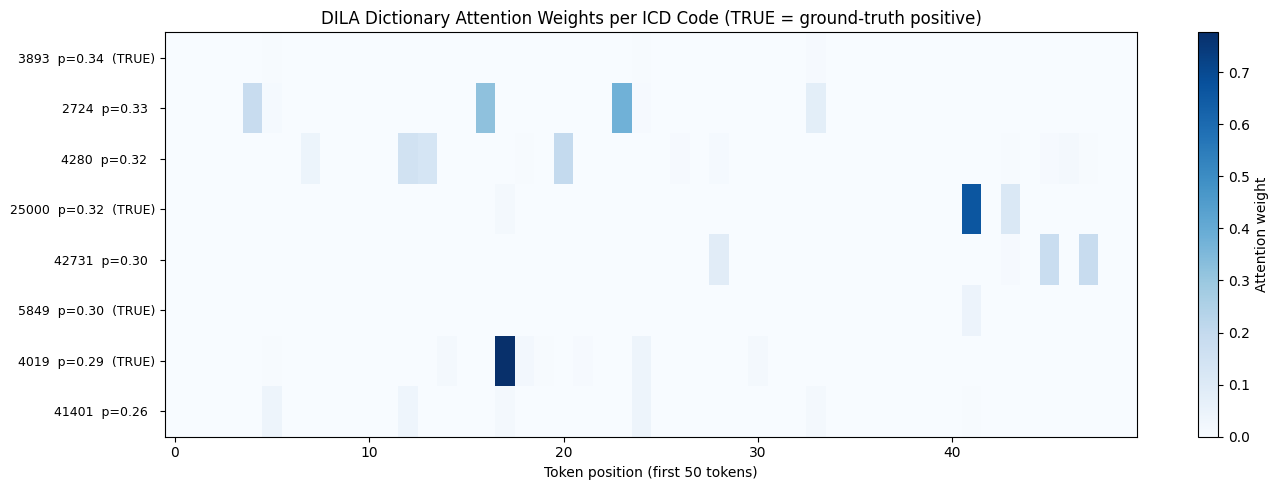

In [ ]:
with torch.no_grad():
    demo_prob = model(
        embeddings=demo_emb.unsqueeze(0).to(DEVICE).float()
    )["y_prob"][0].cpu().numpy()

# Use list to avoid negative-stride numpy indexing into torch tensors
top_pred_indices = list(np.argsort(demo_prob)[::-1][:8])
top_pred_codes   = [idx_to_code[int(i)] for i in top_pred_indices]
top_pred_probs   = demo_prob[np.array(top_pred_indices)]

n_tokens   = min(50, demo_emb.size(0))
attn_np    = attn_mat.numpy()   # (num_labels, seq_len)
attn_slice = attn_np[top_pred_indices, :n_tokens]  # plain list index

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(attn_slice, aspect="auto", cmap="Blues", vmin=0)
ax.set_yticks(range(len(top_pred_codes)))
labels_y = []
for c, p in zip(top_pred_codes, top_pred_probs):
    marker = "(TRUE)" if c in demo_label else ""
    labels_y.append(f"{c}  p={p:.2f}  {marker}")
ax.set_yticklabels(labels_y, fontsize=9)
ax.set_xlabel("Token position (first 50 tokens)")
ax.set_title("DILA Dictionary Attention Weights per ICD Code (TRUE = ground-truth positive)")
plt.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()


## 13. Summary & Conclusions

### What we demonstrated

| Step | What happened |
|------|---------------|
| Data loading | `MIMIC3Dataset` + `MIMIC3ICD9Coding` via PyHealth |
| Feature extraction | Token-level embeddings from `roberta-base` (768-dim) |
| Stage 1 | `SparseAutoencoder` pretrained on raw PLM embeddings (`pretrain_sparse_autoencoder`) |
| Stage 2 | Full `DILA` model trained with combined BCE + SAE loss |
| Evaluation | Multilabel metrics matching the paper's evaluation protocol |

### Reproducing paper results

To fully reproduce **Table 1** from arXiv 2409.10504:

1. **Full MIMIC-III** — set `DEV_MODE = False` and `TOP_N_CODES = None` (all ~8,692 codes)
2. **Biomedical PLM** — replace `PLM_NAME` with `"RoBERTa-base-PM-M3-Voc-hf"` (fine-tuned on PubMed + MIMIC discharge notes)
3. **Longer training** — set `SAE_PRETRAIN_EPOCHS = 10`, `DILA_TRAIN_EPOCHS = 20`
4. **Larger dictionary** — set `DICT_SIZE = 4096` (= 8 × 512 for alpha=8 in the paper; requires more VRAM)
5. **ICD projection init** — call `DictionaryLabelAttention.compute_icd_projection_init()` using the trained SAE and ICD description text, then `model.dict_label_att.initialize_from_icd_descriptions(proj_init)` before Stage-2 training
6. **Multiple seeds** — average results over 3 runs as in the paper

### DILA paper reported results (Table 1, MIMIC-III full)

| Method | Micro-F1 | Macro-F1 | Micro-AUC | Macro-AUC |
|--------|----------|----------|-----------|----------|
| LAAT (baseline) | ~0.601 | ~0.332 | ~0.952 | ~0.930 |
| **DILA (DMA)**  | ~0.596 | ~0.323 | ~0.951 | ~0.927 |

*DILA achieves competitive predictive performance while providing interpretable, dictionary-grounded explanations for each ICD code prediction.*

In [ ]:
# ── Final summary printout ────────────────────────────────────────────────────
summary = {
    "Dataset"         : f"MIMIC-III {'(dev subset)' if DEV_MODE else '(full)'}",
    "PLM"             : PLM_NAME,
    "Num ICD codes"   : NUM_LABELS,
    "Train/Val/Test"  : f"{len(train_samples)}/{len(val_samples)}/{len(test_samples)}",
    "Dict size (m)"   : DICT_SIZE,
    "SAE epochs"      : SAE_PRETRAIN_EPOCHS,
    "DILA epochs"     : DILA_TRAIN_EPOCHS,
    "Threshold"       : THRESHOLD,
    "Micro-F1"        : f"{test_metrics['f1_micro']:.4f}",
    "Macro-F1"        : f"{test_metrics['f1_macro']:.4f}",
    "Micro-AUC"       : f"{test_metrics['roc_auc_micro']:.4f}",
    "Macro-AUC"       : f"{test_metrics['roc_auc_macro']:.4f}",
}

print("\n" + "=" * 50)
print(" DILA Evaluation Summary")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<22} {v}")
print("=" * 50)


 DILA Evaluation Summary
  Dataset                MIMIC-III (full)
  PLM                    allenai/biomed_roberta_base
  Num ICD codes          50
  Train/Val/Test         4000/2000/1000
  Dict size (m)          4096
  SAE epochs             10
  DILA epochs            20
  Threshold              0.3
  Micro-F1               0.3095
  Macro-F1               0.1525
  Micro-AUC              0.7426
  Macro-AUC              0.6449
